In [1]:
from typing import Annotated, Sequence, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, ToolMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

In [2]:
load_dotenv()

True

In [3]:
MODEL = "gpt-5.4-mini"

In [4]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [5]:
@tool 
def weather():
    """
    Tool func where weather api data is called and fetched 
    """

    return "The weather is sunny today"

@tool 
def websearch():
    """
    Tool func for web search
    """

    return "SCRAPPED DATA: Bitcoin has fallen down to the last support level!" 


@tool
def calculate():
    """
    Tool func used in case of calculation needed
    """ 

    result = 43 
    return result    

In [6]:
tools = [weather, websearch, calculate]
llm = ChatOpenAI(model=MODEL).bind_tools(tools)

In [7]:
def llm_agent(state):
    system_message = SystemMessage(content="You are a helpful assistant answering user queries")

    response = llm.invoke([system_message] + state["messages"])
    # print("AI: ", response.content)

    return {"messages": [response]}

In [8]:
def should_continue(state): 
    """
    Conditional node that decides whether to continue or end the tool calling
    """

    messages = state["messages"]
    last_message = messages[-1]

    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"

In [9]:
builder = StateGraph(State)

builder.add_node("llm_agent", llm_agent)

tool_node = ToolNode(tools=tools)
builder.add_node("tools", tool_node)

builder.add_edge(START, "llm_agent")
builder.add_conditional_edges(
    "llm_agent",
    should_continue,
    {
        "continue": "tools",
        "end": END
    }
)
builder.add_edge("tools", "llm_agent")

graph = builder.compile()

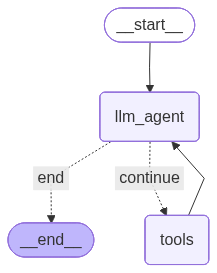

In [10]:
builder.compile()

In [11]:
### Regular Output

graph.invoke({
    "messages": [
        ("user", "how's bitcoin going?")
    ]
})

{'messages': [HumanMessage(content="how's bitcoin going?", additional_kwargs={}, response_metadata={}, id='49b51d5c-5984-43eb-b072-e9e1912b6cff'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 169, 'total_tokens': 182, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DpdhOfUGHqvIAKuOsY8mEDHE7kone', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eb7c6-87a2-7302-888d-c5066bc7891b-0', tool_calls=[{'name': 'websearch', 'args': {}, 'id': 'call_6UDBbkdCZSESCnUL5LUR27CM', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 169, 'output_tokens': 13, 'total_tokens': 182

In [14]:
def print_stream(stream): 
    for s in stream: 
        # print("===================STREAM==================\n", f"{s}\n")
        print(f"{s}\n\n\n")
        # message = s.get("llm_agent", "tools")

        # print(f"MESSAGE: {message}\n\n\n")

In [15]:
### Stream Output

input_arg = {
    "messages": [
        ("user", "how's bitcoin going?")
    ]
}

print_stream(graph.stream(input_arg))

{'llm_agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 169, 'total_tokens': 182, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-DpdhrLSeo0gyTot0Fw5KlTi4tSbsc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019eb7c6-faa0-7030-b86d-2c37fb8e1334-0', tool_calls=[{'name': 'websearch', 'args': {}, 'id': 'call_qq3mt0xc19wHNHszmaPPxMQR', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 169, 'output_tokens': 13, 'total_tokens': 182, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}



{'to